In [107]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [108]:
# Caminhos padrões para os arquivos e pastas
caminho_processed = "../dados/processed"
caminho_gold = "../dados/gold"

In [109]:
# Visualização das colunas de dados 'float' para somente 2 casas decimais
pd.set_option('display.float_format', '{:,.2f}'.format)

In [110]:
df_analitico = pd.read_parquet(os.path.join(caminho_gold, "df_gold.parquet"))

# --- SOLVÊNCIA & CAPACIDADE ---
# Alavancagem Inversa -> Quanto do Ativo é dinheiro dos sócios?
df_analitico['kpi_basileia'] = df_analitico['patrimonio_liquido'] / df_analitico['ativo_total']

# --- RENTABILIDADE ---
# ROE (Return on Equity)
df_analitico['kpi_roe'] = df_analitico['lucro_liquido'] / df_analitico['patrimonio_liquido']

# --- QUALIDADE ---
# Dependência de "Outras Receitas".
# Se o banco depende muito de receitas não-operacionais, isso é não recorrente.
# Fórmula: Outras Receitas / (Total de Receitas Operacionais)
df_analitico['receita_total_estimada'] = df_analitico['resultado_intermediacao'] + df_analitico['outras_receitas_despesas'] + df_analitico['resultado_pagamentos'].fillna(0)

df_analitico['kpi_qualidade_lucro'] = df_analitico['outras_receitas_despesas'] / df_analitico['receita_total_estimada']

# --- VOLUMETRIA ---
# Tamanho do Banco (Log) para separar Pequenos de Gigantes
df_analitico['tamanho_log'] = np.log10(df_analitico['ativo_total'])

df_analitico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17170 entries, 0 to 17169
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   instituicao                17170 non-null  string        
 1   data_base                  17170 non-null  datetime64[ns]
 2   codigo_bacen               17170 non-null  Int64         
 3   conglomerado               8373 non-null   category      
 4   tcb                        17170 non-null  category      
 5   tc                         17170 non-null  Int64         
 6   ti                         17170 non-null  Int64         
 7   cidade                     17170 non-null  string        
 8   uf                         17170 non-null  category      
 9   ativo_total                17042 non-null  float64       
 10  captacoes                  17042 non-null  float64       
 11  patrimonio_liquido         17042 non-null  float64       
 12  lucr

c:\Users\Thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [111]:
grupo_master = df_analitico[df_analitico['instituicao'].str.contains("MASTER", na=False, case=False)].copy()

colunas_visualizar = [
    'data_base',
    'instituicao', 
    'ativo_total',          # Tamanho
    'lucro_liquido',        # Resultado
    'kpi_roe',              # Rentabilidade
    'kpi_basileia',         # Solvência
    'kpi_qualidade_lucro',  # Dependência de Outras Receitas
    'patrimonio_liquido'   
]

tabela_dinamica = grupo_master[colunas_visualizar].pivot_table(
    index='instituicao',
    columns='data_base',
    values='ativo_total',
    aggfunc='sum'
).fillna(0)

display(tabela_dinamica)

data_base,2022-12-01,2023-03-01,2023-06-01,2023-09-01,2023-12-01,2024-03-01,2024-06-01,2024-09-01,2024-12-01,2025-03-01,2025-06-01
instituicao,,,,,,,,,,,
BANCO MASTER DE INVESTIMENTO S.A.,"24,859.00","132,165.00","331,553.00","871,777.00","3,128,017.00","6,245,229.00","10,303,227.00","12,760,087.00","13,135,183.00","13,062,273.00","14,472,654.00"
BANCO MASTER MÚLTIPLO S.A.,0.00,0.00,0.00,0.00,0.00,0.00,"389,985.00","744,065.00","799,930.00","420,976.00","703,935.00"
BANCO MASTER S/A,"20,541,658.00","23,077,706.00","27,331,844.00","30,857,830.00","36,141,586.00","41,044,131.00","50,985,793.00","58,335,368.00","63,014,692.00","68,344,170.00",0.00
"MASTER S/A CORRETORA DE CÂMBIO, TÍTULOS E VALORES MOBILIÁRIOS","58,249.00","39,265.00","51,279.00","40,856.00","44,575.00","91,132.00","41,569.00","38,040.00","48,115.00","828,479.00","49,653.00"


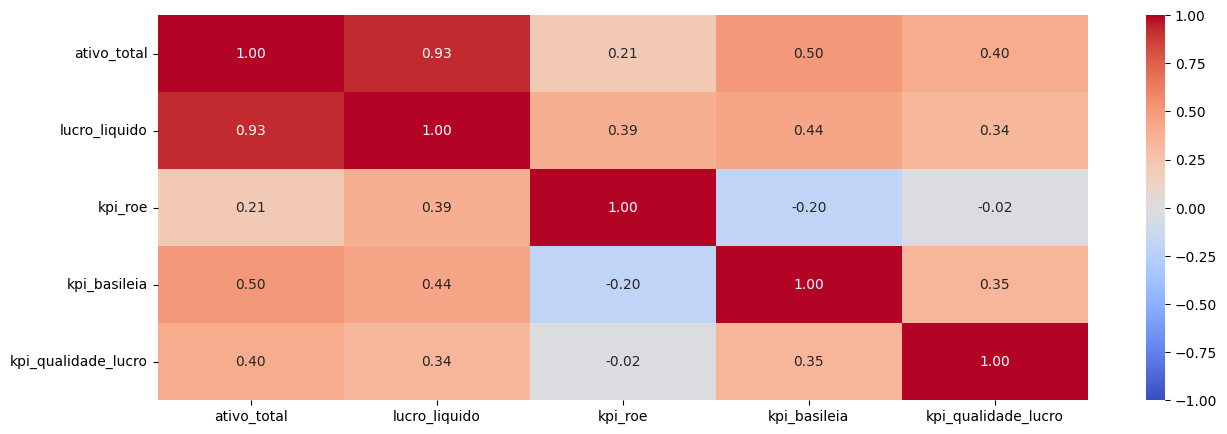

In [112]:
bancos = [
    'BANCO MASTER S/A',       # Alvo
    'BANCO DAYCOVAL S.A.',    # Benchmark (Médio saudável)
    'BANCO PAN S.A.',         # Benchmark (Varejo agressivo)
    'BANCO BTG PACTUAL S.A.'  # Benchmark (Banco de Investimento Gigante)
]

colunas_visualizar = [
    'instituicao', 
    'ativo_total',          # Tamanho
    'lucro_liquido',        # Resultado
    'kpi_roe',              # Rentabilidade
    'kpi_basileia',         # Solvência
    'kpi_qualidade_lucro'   # Dependência de Outras Receitas
]

df_bancos = df_analitico.loc[df_analitico['instituicao'].isin(bancos),colunas_visualizar].copy()


correlação_bancos = df_bancos.corr(
    method='pearson',
    numeric_only=True
)

plt.figure(figsize=(15,5))
sns.heatmap(
    correlação_bancos,
    annot=True,       # Isso escreve os valores nos quadrados
    fmt=".2f",        # Formata para 2 casas decimais (ex: 0.85)
    cmap='coolwarm',  # Esquema de cores (Azul = negativo, Vermelho = positivo)
    vmin=-1, vmax=1,  # Garante que a escala de cores vá de -1 a 1
    center=0          # Garante que o branco/neutro seja o zero
)

plt.show()

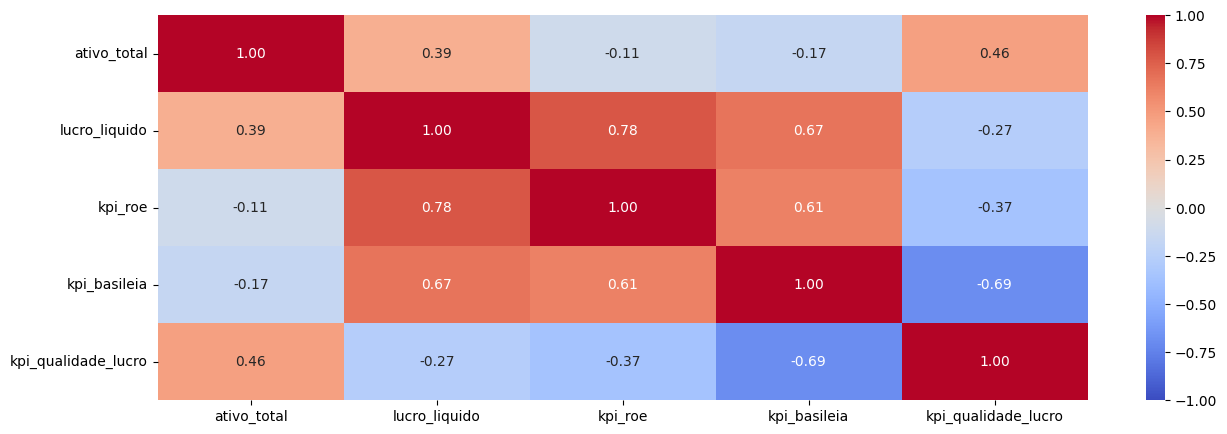

In [113]:
df_master = df_analitico.loc[df_analitico['instituicao'] == 'BANCO MASTER S/A',colunas_visualizar].copy()

correlação_master = df_master.corr(
    method='pearson',
    numeric_only=True
)

plt.figure(figsize=(15,5))
sns.heatmap(
    correlação_master,
    annot=True,       # Isso escreve os valores nos quadrados
    fmt=".2f",        # Formata para 2 casas decimais (ex: 0.85)
    cmap='coolwarm',  # Esquema de cores (Azul = negativo, Vermelho = positivo)
    vmin=-1, vmax=1,  # Garante que a escala de cores vá de -1 a 1
    center=0          # Garante que o branco/neutro seja o zero
)

plt.show()

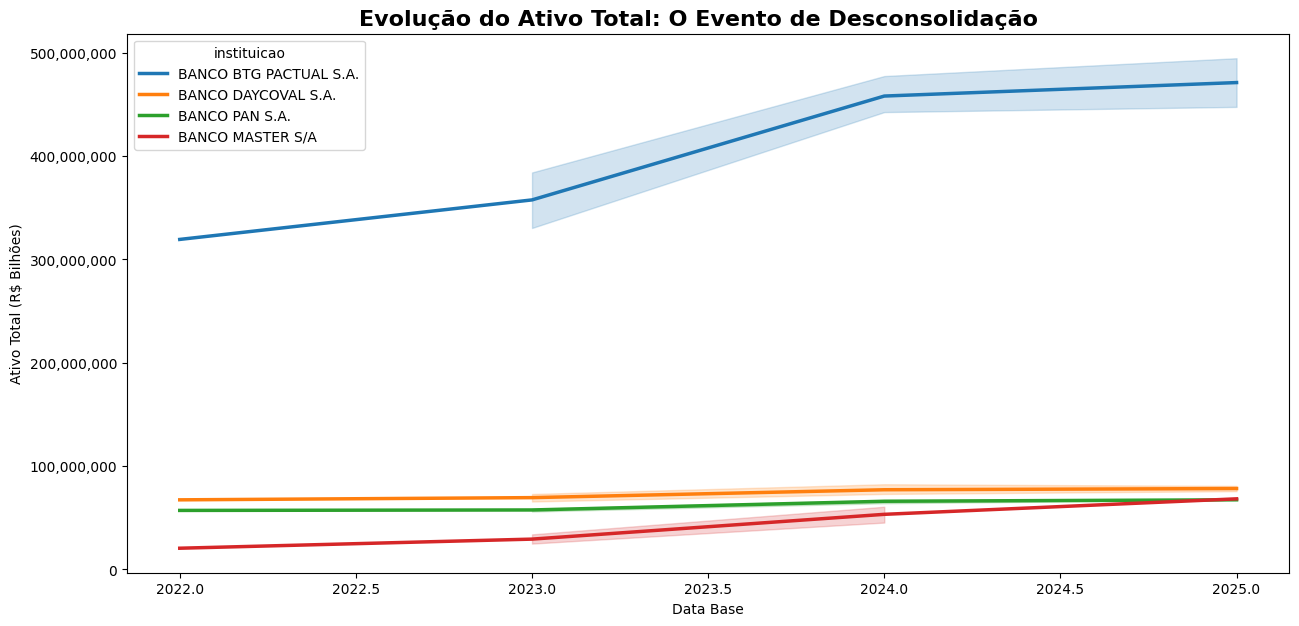

In [119]:
bancos = [
    'BANCO MASTER S/A',       # Alvo
    'BANCO DAYCOVAL S.A.',    # Benchmark (Médio saudável)
    'BANCO PAN S.A.',         # Benchmark (Varejo agressivo)
    'BANCO BTG PACTUAL S.A.'  # Benchmark (Banco de Investimento Gigante)
]

df_analitico['Year'] = df_analitico['data_base'].dt.year

df_bancos = df_analitico.loc[df_analitico['instituicao'].isin(bancos)].copy()

plt.figure(figsize=(15,7))

sns.lineplot(
    data=df_bancos,
    x='Year',
    y='ativo_total',
    hue='instituicao',
    linewidth=2.5
)


ax = plt.gca() # Pega o eixo atual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Evolução do Ativo Total: O Evento de Desconsolidação', fontsize=16, fontweight='bold', loc='left', x=0.2)
plt.ylabel('Ativo Total (R$ Bilhões)')
plt.xlabel('Data Base')
plt.show()

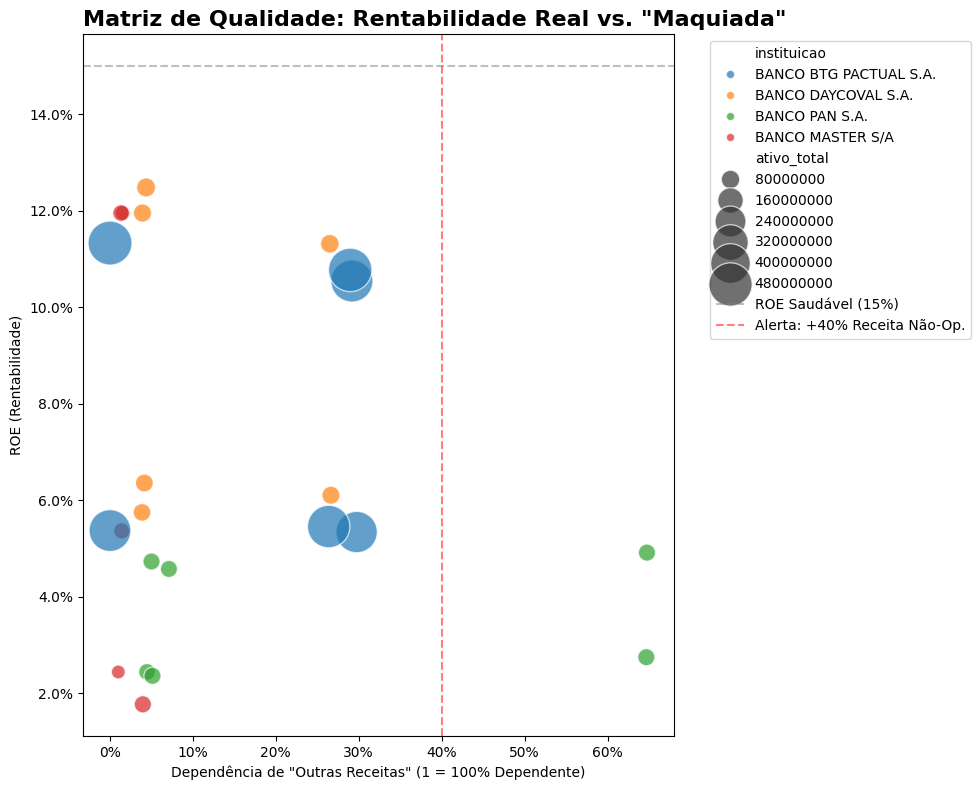

In [ ]:
plt.figure(figsize=(10, 8))

# Vamos pegar a média do último ano para não ficar muito poluído
df_recente = df_bancos[df_bancos['data_base'] >= '2024-01-01'].copy()

sns.scatterplot(
    data=df_recente,
    x='kpi_qualidade_lucro',
    y='kpi_roe',
    hue='instituicao',
    size='ativo_total', # Bolinha maior = Banco maior
    sizes=(100, 1000),
    alpha=0.7,
    palette='tab10'
)

# Linhas de Referência (Quadrantes)
plt.axhline(y=0.15, color='gray', linestyle='--', alpha=0.5, label='ROE Saudável (15%)')
plt.axvline(x=0.40, color='red', linestyle='--', alpha=0.5, label='Alerta: +40% Receita Não-Op.') 

plt.title('Matriz de Qualidade: Rentabilidade Real vs. "Maquiada"', fontsize=16, fontweight='bold', loc='left')
plt.ylabel('ROE (Rentabilidade)')
plt.xlabel('Dependência de "Outras Receitas" (1 = 100% Dependente)')

# Formatações de %
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.gca().xaxis.set_major_formatter(ticker.PercentFormatter(1.0))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

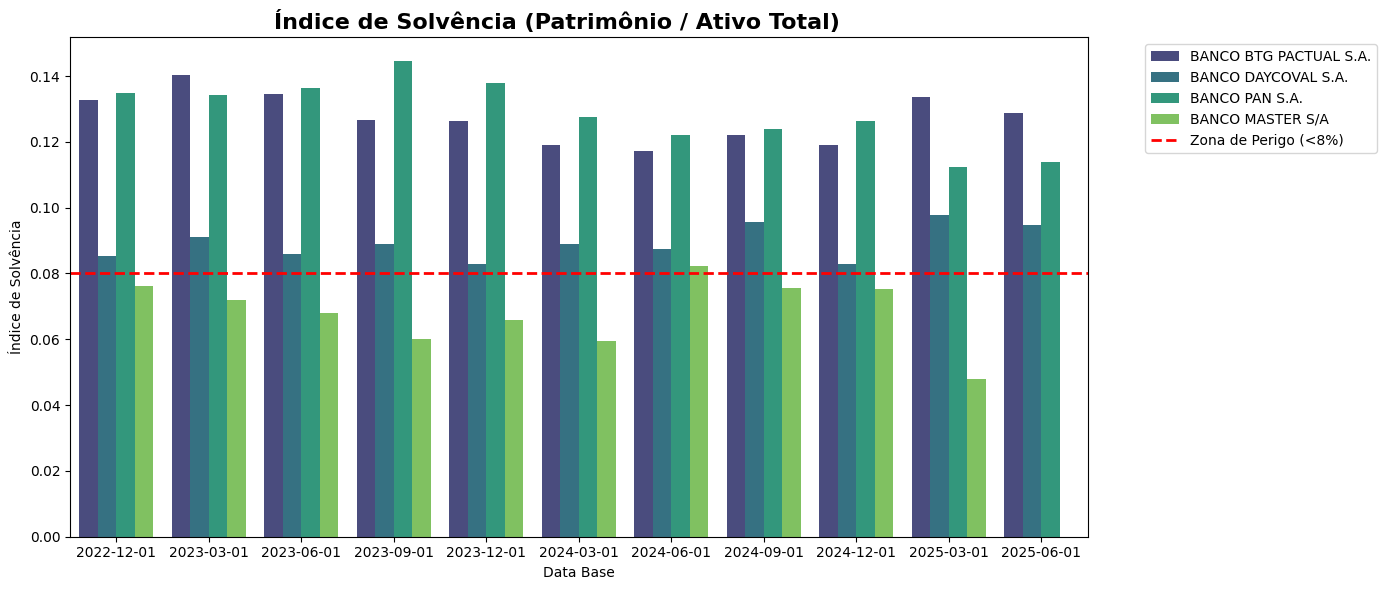

In [138]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_bancos,
    x='data_base',
    y='kpi_basileia',
    hue='instituicao',
    palette='viridis'
)

plt.title('Índice de Solvência (Patrimônio / Ativo Total)', fontsize=16, fontweight='bold', loc='left', x=0.2)
plt.ylabel('Índice de Solvência')
plt.xlabel('Data Base')

# Linha de Perigo (Bancos costumam quebrar abaixo de 5-8% de capital próprio real)
plt.axhline(y=0.08, color='red', linestyle='--', linewidth=2, label='Zona de Perigo (<8%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()